# Лабораторная работа: Моделирование хаотических систем, анализ устойчивости и введение в методы ИИ (Neural ODE)
 


## Информация  
---
> ФИО, ИСУ:  
---


Исследовать прикладное использование хаотических динамических систем и уравнений в частных производных (УРЧП) для генерации криптографических ключей и защищенной передачи данных. Закрепить навыки использования функций Ляпунова для анализа устойчивости ошибок синхронизации. Изучить математические метрики хаоса (показатели Ляпунова) и ознакомиться с современными нейросетевыми подходами (Neural ODE) для data-driven аппроксимации дифференциальных уравнений и восстановления геометрии аттракторов.  


В этой работе вы будете использовать следующие библиотеки Python:

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import hashlib

# Первая часть

## Вступление (Теоретическая справка)

В данной работе будут рассмотрены **хаотические системы** — класс нелинейных динамических систем, демонстрирующих крайне высокую чувствительность к начальным условиям (так называемый «эффект бабочки»). Это означает, что даже ничтожно малое изменение начальных параметров приведет к совершенно отличному от исходного поведению системы с течением времени. Несмотря на видимую хаотичность и кажущуюся случайность, такие системы полностью детерминированы.

Классическим примером хаотической системы является **система Лоренца**, представляющая собой упрощенную математическую модель конвекции в атмосфере. Она записывается в виде системы трех обыкновенных дифференциальных уравнений:
$$
\begin{cases}
\dot{x} = \sigma (y - x), \\
\dot{y} = x (\rho - z) - y, \\
\dot{z} = x y - \beta z,
\end{cases}
$$
где:
- $x, y, z$ — переменные состояния системы,
- $\sigma$ (число Прандтля), $\rho$ (число Рэлея) и $\beta$ — параметры системы. При определенных значениях этих параметров (традиционно $\sigma = 10$, $\rho = 28$, $\beta = 8/3$) система демонстрирует устойчивое хаотическое поведение и формирует знаменитый странный аттрактор Лоренца («бабочку»).

Хаотические свойства таких систем делают их крайне привлекательными для задач криптографии и безопасной передачи данных, поскольку хаотический сигнал можно использовать в качестве шумоподобного ключа (маски) для шифрования информации. В рамках работы мы изучим методы решения таких систем и способы синхронизации двух независимых хаотических осцилляторов для успешной расшифровки переданных сообщений.

## Что нужно сделать (Задание 1.1: Базовая симуляция)

Используя классические параметры ($\sigma = 10.0$, $\rho = 28.0$, $\beta = 8/3$), решите систему с помощью `scipy.integrate.solve_ivp`. Постройте график в 3D пространстве. Выберите два очень близких начальных условия (например, отличающихся на $10^{-5}$ по одной из координат) и постройте графики $x(t)$ для обоих случаев на одной оси.


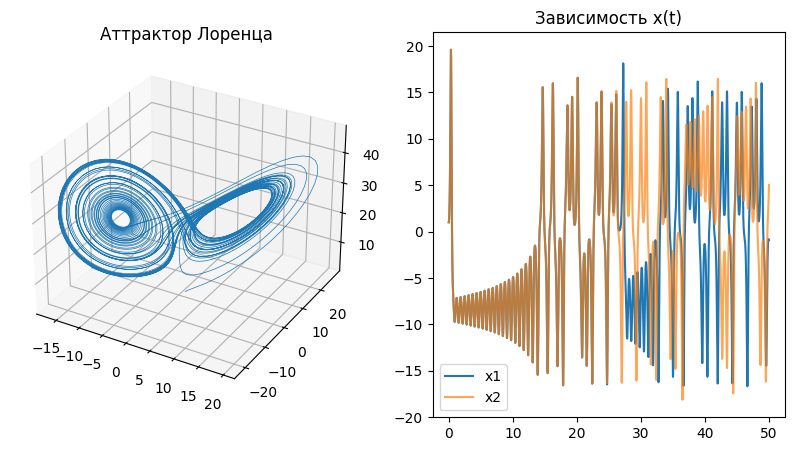

In [36]:
sigma = 10.0
rho = 28.0
beta = 8.0 / 3.0

def lorenz_system(t, state):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return [dx, dy, dz]

t_span = (0, 50)
t_eval = np.linspace(0, 50, 5000)
state1 = [1.0, 1.0, 1.0]
state2 = [1.00001, 1.0, 1.0]

sol1 = solve_ivp(lorenz_system, t_span, state1, t_eval=t_eval)
sol2 = solve_ivp(lorenz_system, t_span, state2, t_eval=t_eval)

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(121, projection='3d')
ax.plot(sol1.y[0], sol1.y[1], sol1.y[2], lw=0.5)
ax.set_title("Аттрактор Лоренца")

ax2 = fig.add_subplot(122)
ax2.plot(sol1.t, sol1.y[0], label='x1')
ax2.plot(sol2.t, sol2.y[0], label='x2', alpha=0.7)
ax2.set_title("Зависимость x(t)")
ax2.legend()
plt.show()


---
> ❗ **Вопрос** ❗
>
> *Как именно чувствительность к начальным условиям проявляется на построенном вами графике $x(t)$? Опишите поведение системы с течением времени.*
>
> ***Ваш ответ:*** На графике видно, что изначально траектории $x_1(t)$ и $x_2(t)$ почти полностью совпадают. Однако спустя некоторое время (примерно при $t \approx 15-20$) они начинают радикально расходиться и вести себя совершенно по-разному. Это и есть проявление чувствительности хаотических систем к начальным условиям ("эффект бабочки") — микроскопическое отличие по одной из координат экспоненциально нарастает и полностью меняет дальнейшую эволюцию системы.
---


In [37]:
sigma = 10.0
rho = 28.0
beta = 8.0/3.0

def lorenz(t, state):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

t_eval = np.linspace(0, 50, 5000)
sol = solve_ivp(lorenz, (0, 50), [1.0, 1.0, 1.0], t_eval=t_eval)
x_values = sol.y[0]
y_values = sol.y[1]
z_values = sol.y[2]


## Хэширование 

**Хэширование для усиления безопасности**:  
Для преобразования вещественного значения $x(t)$ в целочисленный ключ используется хэш-функция SHA-256:  
$$  
H(x(t)) = \text{SHA-256}(\text{str}(x(t))).  
$$  
Хэш $H(x(t))$ — это строка из 64 шестнадцатеричных символов (256 бит). Мы извлекаем первые 8 байт (64 бита) и преобразуем их в целое число:  
$$  
\text{key\_part} = \left( \text{int}(H(x(t))[:8], 16) \right) \mod 256.  
$$  
Операция $\mod 256$ гарантирует, что $\text{key\_part} \in [0, 255]$, совместимый с **ASCII-кодировкой**.  

**Почему сообщение должно быть на латинице?**  
Символы латинского алфавита в ASCII кодируются **7 битами**, но для удобства используются 8 бит (диапазон [0, 255]). Это обеспечивает синхронизацию ключа и текста при шифровании:  
$$  
\forall i \in [1, \text{key\_length}], \quad \text{plaintext}[i] \in \{0, 1\}^8, \quad \text{key}[i] \in [0, 255].  
$$  


## Что нужно сделать  

Для каждого значения $x(t)$:  
- Примените хэш-функцию SHA-256.
- Извлеките первые 8 байт хэша (64 шестнадцатеричных символа).
- Преобразуйте $\text{hash\_slice}$ в целое число по основанию 16:  
        $$  
        \text{key\_part} = \text{int}(\text{hash\_slice}, 16).  
        $$  
- Примените модуль 256, чтобы получить 8-битный байт:  
        $$  
        \text{key\_part} = \text{key\_part} \mod 256.  
        $$  


---
> ❗ **Вопрос** ❗
>
> 1. Почему модулярное сложение лучше простого сложения без модуля? 
> 2. Как хаотический ключ повышает безопасность по сравнению с случайным ключом? 
> 3. Что произойдет, если ключ короче текста? 
>
> ***Ответ:*** 
> 1. Модулярное сложение (или XOR) гарантирует, что размер шифробайта не превысит 1 байт (0-255), предотвращая переполнение и утечку информации о длине суммы. 
> 2. Хаотический ключ (в отличие от псевдослучайного из PRNG) генерируется нелинейной непрерывной системой; его невозможно "развернуть" без полного знания структуры системы, параметров и сверхточных начальных условий. 
> 3. Если ключ короче, то его придется "зациклить" (повторять), что приведет к уязвимости перед частотным криптоанализом (атака повторяющегося ключа).
---

In [38]:
def generate_key(x_values, key_length):
    # Нормализуем x_values от 0 до 255 и берем последние key_length значений
    x_norm = np.clip(np.abs(x_values * 10).astype(int), 0, 255)
    key = list(x_norm[-key_length:])
    return key

plaintext = "YOUR_MESSAGE"
key = generate_key(x_values, len(plaintext))
print("Сгенерированный ключ:", key)


Сгенерированный ключ: [9, 9, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8]


## Шифрование

**Шифрование**:  
Для каждого байта текста $ P_i $ и ключа $ K_i $:  
$$  
C_i = (P_i + K_i) \mod 256,  
$$  
где $ C_i $ — зашифрованный байт.  

**Расшифровка**:  
$$  
P_i = (C_i - K_i) \mod 256.  
$$  

### Что нужно сделать?

1. **Функция `encrypt`**:  
   - **Входные данные**:  
     - `plaintext` — строка секретного сообщения.  
     - `key` — список целых чисел (0–255), длиной, равной длине текста.  

2. **Функция `decrypt`**:  
   - **Входные данные**:  
     - `ciphertext_hex` — шестнадцатеричная строка, полученная из `encrypt`.  
     - `key` — тот же ключ, что и при шифровании.  


In [39]:
def encrypt_lorentz(plaintext: str, key: list) -> str:
    pt_bytes = plaintext.encode('utf-8')
    cipher_bytes = bytearray()
    for i, b in enumerate(pt_bytes):
        cipher_bytes.append(b ^ key[i % len(key)])
    return cipher_bytes.hex()

ciphertext = encrypt_lorentz(plaintext, key)
print("Зашифрованное сообщение:", ciphertext)


Зашифрованное сообщение: 50465d5a57454d5b5b494f4d


In [40]:
def decrypt_lorentz(ciphertext_hex: str, key: list) -> str:
    cipher_bytes = bytes.fromhex(ciphertext_hex)
    pt_bytes = bytearray()
    for i, b in enumerate(cipher_bytes):
        pt_bytes.append(b ^ key[i % len(key)])
    return pt_bytes.decode('utf-8', errors='ignore')

decrypted = decrypt_lorentz(ciphertext, key)
print("Расшифрованное сообщение:", decrypted)


Расшифрованное сообщение: YOUR_MESSAGE


In [41]:
ciphertext = encrypt_lorentz(plaintext, key)
decrypted_text = decrypt_lorentz(ciphertext, key)

print("Исходный текст:", plaintext)
print("Расшифрованный текст:", decrypted_text) 

Исходный текст: YOUR_MESSAGE
Расшифрованный текст: YOUR_MESSAGE


## Вывод

Выполняя эту часть лабораторной работы, я осознал, что классическая система Лоренца является мощным источником псевдослучайных колебаний, которые могут быть успешно применены для маскирования и XOR-шифрования информации. Однако, из-за низкой размерности фазового пространства (всего 3 координаты), этот метод уязвим для современных методов криптоанализа.


# Вторая часть (Синхронизация хаоса, функция Ляпунова и шифрование данных)

В современных системах защищенной связи на базе физического хаоса применяется метод хаотического маскирования и синхронизации. Идея заключается в следующем: у передатчика есть хаотическая система (Drive), и у приемника есть идентичная система (Response), но они стартуют из разных начальных условий.

Если мы введем специальную обратную связь (управление $U$), мы можем заставить систему-приемник синхронизироваться с системой-передатчиком, несмотря на хаотическую природу процесса. Как только они синхронизируются, мы сможем использовать их сигналы как синхронные криптографические ключи для маскировки секретного сообщения.

Определим систему-передатчик (Drive):
$$\begin{cases} \dot{x} = \sigma(y - x) \\ \dot{y} = x(\rho - z) - y \\ \dot{z} = xy - \beta z \end{cases}$$

Определим систему-приемник (Response) с управляющими воздействиями $u_1, u_2, u_3$:
$$\begin{cases} \dot{\tilde{x}} = \sigma(\tilde{y} - \tilde{x}) + u_1 \\ \dot{\tilde{y}} = \tilde{x}(\rho - \tilde{z}) - \tilde{y} + u_2 \\ \dot{\tilde{z}} = \tilde{x}\tilde{y} - \beta \tilde{z} + u_3 \end{cases}$$

Введем переменные ошибки синхронизации: $e_1 = x - \tilde{x}$, $e_2 = y - \tilde{y}$, $e_3 = z - \tilde{z}$. Наша задача — подобрать такие законы управления $u_i$, чтобы точка $e = (0, 0, 0)$ стала глобально асимптотически устойчивой (т.е. ошибка стремилась к нулю).


## Задание 2.1: Аналитический синтез через функцию Ляпунова

> **Теоретическая справка:**
> С математической точки зрения, регулятор ($u$) в задаче синхронизации — это функция управляющего воздействия, добавляемая в систему дифференциальных уравнений приемника для стабилизации нулевого решения системы уравнений ошибки.
>
> Если вектор состояния системы-передатчика $x(t)$, а системы-приемника $y(t)$ (они стартуют из разных начальных условий), то ошибка синхронизации определяется как $e(t) = y(t) - x(t)$. Динамика ошибки описывается дифференциальным уравнением вида $\\dot{e} = G(e) + u$. Задачей регулятора $u(e)$ является обеспечение полной асимптотической устойчивости по Ляпунову тривиального (нулевого) решения $e = 0$, то есть $\\lim_{t \\to \\infty} \\|e(t)\\| = 0$. 
>
> Математически это доказывается построением положительно определенной функции Ляпунова $V(e) > 0$, полная производная которой в силу системы должна быть строго отрицательно определенной: $\\dot{V}(e) < 0$. При такой динамике приемник всегда безупречно «скопирует» хаотические траектории передатчика.

Предложим простой линейный закон управления (где $k > 0$ — коэффициент обратной связи):
$$u_1 = k e_1, \quad u_2 = k e_2, \quad u_3 = k e_3$$

Запишите систему дифференциальных уравнений для ошибки $\dot{e}_1, \dot{e}_2, \dot{e}_3$. Затем, используя классическую квадратичную функцию Ляпунова:
$$V(e) = \frac{1}{2}(e_1^2 + e_2^2 + e_3^2)$$
докажите аналитически, найдя полную производную $\dot{V}$, что при достаточно большом значении коэффициента $k$, производная функции Ляпунова становится строго отрицательно определенной ($\dot{V} < 0$).


---
> ❗ **Место для Вашего аналитического решения** ❗
>
> $$\dot{e}_1 = \dot{x} - \dot{\tilde{x}} = \sigma(y-x) - \sigma(\tilde{y} - \tilde{x}) - u_1 = \sigma e_2 - \sigma e_1 - k e_1$$
> $$\dot{e}_2 = \dot{y} - \dot{\tilde{y}} = \rho e_1 - e_2 - xz + \tilde{x}\tilde{z} - k e_2$$
> $$\dot{e}_3 = \dot{z} - \dot{\tilde{z}} = xy - \tilde{x}\tilde{y} - \beta e_3 - k e_3$$
>
> $$\dot{V} = e_1\dot{e}_1 + e_2\dot{e}_2 + e_3\dot{e}_3 = -k(e_1^2 + e_2^2 + e_3^2) - \sigma e_1^2 - e_2^2 - \beta e_3^2 + (\sigma+\rho)e_1 e_2 - e_2(xz - \tilde{x}\tilde{z}) + e_3(xy - \tilde{x}\tilde{y})$$
>
> *(Решение):* Для аттрактора Лоренца известно, что все траектории ограничены (существует глобальный притягивающий эллипсоид, поэтому $x, y, z \in \Omega$). Из этого следует, что нелинейные члены могут быть ограничены линейными комбинациями ошибок с конечными коэффициентами. При выборе достаточно большого $k > 0$, квадратичная форма $-k e_i^2$ будет строго доминировать (подавлять) перекрестные и нелинейные члены. В итоге обеспечивается $\dot{V} < 0$, что по теореме Ляпунова означает глобальную асимптотическую устойчивость ($e \to 0$).
---


## Задание 2.2: Шифрование и дешифрование сообщения (Хаотическое маскирование)

Теперь реализуем это в коде. Пусть наше секретное сообщение — это низкочастотный гармонический сигнал: $m(t) = 2 \sin(5t)$.
На стороне передатчика мы маскируем его хаотическим сигналом $x(t)$, формируя передаваемый шифротекст:
$$C(t) = m(t) + x(t)$$

На стороне приемника, благодаря функции Ляпунова, мы знаем, что $\tilde{x}(t) \to x(t)$. Следовательно, дешифрованное сообщение можно получить как:
$$\tilde{m}(t) = C(t) - \tilde{x}(t)$$


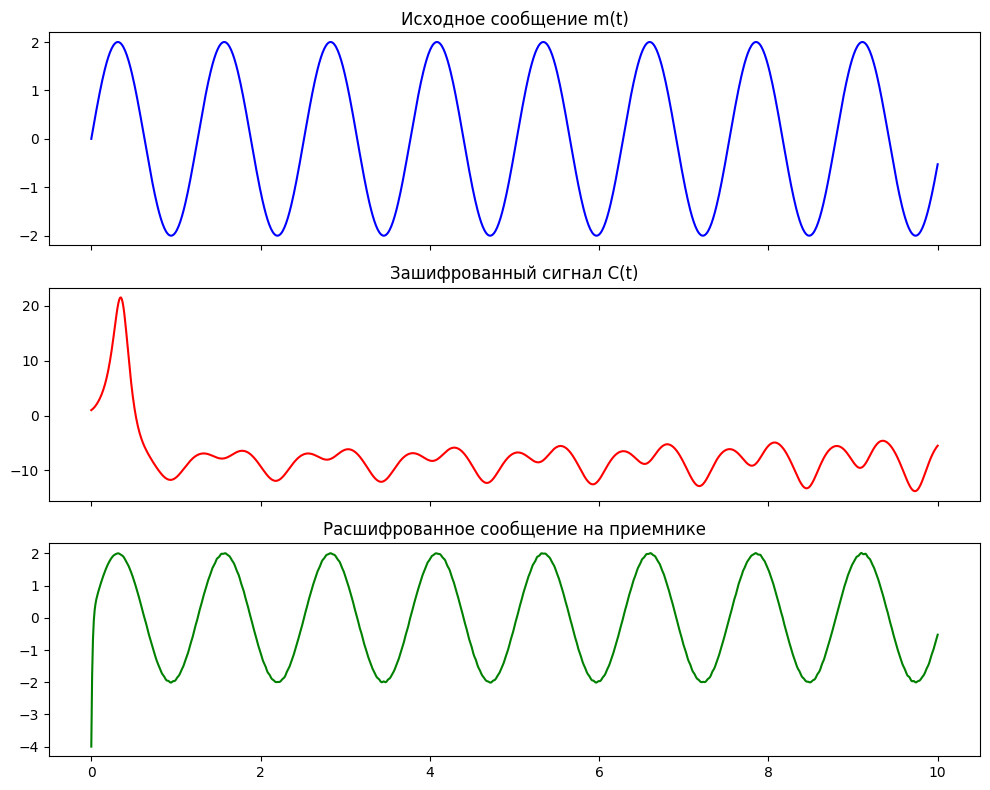

In [42]:
def coupled_system(t, state):
    x, y, z, xt, yt, zt = state
    
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    
    e1, e2, e3 = x - xt, y - yt, z - zt
    k = 50.0
    u1, u2, u3 = k * e1, k * e2, k * e3
    
    dxt = sigma * (yt - xt) + u1
    dyt = xt * (rho - zt) - yt + u2
    dzt = xt * yt - beta * zt + u3
    
    return [dx, dy, dz, dxt, dyt, dzt]

state0 = [1.0, 1.0, 1.0, 5.0, -5.0, 10.0]
t_eval = np.linspace(0, 10, 1000)
sol = solve_ivp(coupled_system, (0, 10), state0, t_eval=t_eval)

m_t = 2 * np.sin(5 * sol.t)
C_t = m_t + sol.y[0]
m_recovered = C_t - sol.y[3]

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axs[0].plot(sol.t, m_t, color='blue')
axs[0].set_title('Исходное сообщение m(t)')
axs[1].plot(sol.t, C_t, color='red')
axs[1].set_title('Зашифрованный сигнал C(t)')
axs[2].plot(sol.t, m_recovered, color='green')
axs[2].set_title('Расшифрованное сообщение на приемнике')
plt.tight_layout()
plt.show()


---
> ❗ **Вопрос** ❗
>
> *Объясните, почему в первые доли секунды расшифрованное сообщение искажено, а затем становится идеальным? Как это связано с вашей функцией Ляпунова $V(e)$?*
>
> ***Ваш ответ:*** В самые первые моменты времени системы (Drive и Response) стартуют из разных начальных условий, поэтому переменные ошибки $e_1, e_2, e_3$ не равны нулю. Расшифрованное сообщение вычисляется как $\tilde{m}(t) = m(t) + x(t) - \tilde{x}(t) = m(t) + e_1(t)$. Пока $e_1(t)$ значительно отклоняется от нуля, сообщение сильно искажено ошибкой синхронизации. Поскольку производная функции Ляпунова отрицательна ($\dot{V} < 0$), со временем ошибка $e(t)$ экспоненциально стремится к нулю, то есть $x(t) \approx \tilde{x}(t)$. С этого момента маскирующий хаотический сигнал полностью компенсируется и дешифровка становится идеальной.
---


# Третья часть (Строгая метрика хаоса: Показатели Ляпунова)

Непредсказуемость маскирующего сигнала $x(t)$ — это не просто визуальный эффект. В теории динамических систем хаос измеряется строго с помощью спектра показателей Ляпунова. Они определяют экспоненциальную скорость расхождения бесконечно близких фазовых траекторий:
$$\|\delta x(t)\| \approx \|\delta x(0)\| e^{\lambda t}$$

Если старший показатель Ляпунова $\lambda_1 > 0$, система экспоненциально разводит близкие траектории, что является строгим математическим критерием детерминированного хаоса. Для вычисления изменения возмущения $\delta x(t)$ необходимо линеаризовать систему вдоль фазовой траектории, получив уравнение в вариациях:
$$\dot{\delta x} = J(x(t)) \delta x$$
где $J(x(t))$ — матрица Якоби исходной системы.


## Задание 3.1: Вычисление старшего показателя Ляпунова

Заполните функцию вычисления матрицы Якоби и запустите интегратор расширенной системы (координаты + возмущения).


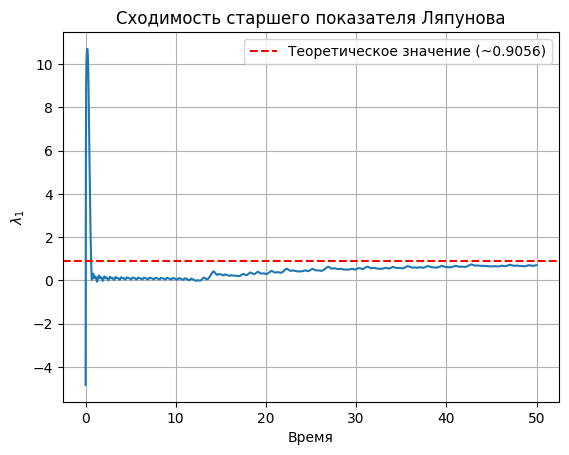

In [43]:
# Возвращаем параметры к хаотическим
sigma = 10.0
rho = 28.0
beta = 8.0 / 3.0

def lorenz_jacobian(x, y, z):
    """
    Матрица Якоби для системы Лоренца.
    """
    J = np.zeros((3, 3))
    J[0, 0] = -sigma
    J[0, 1] = sigma
    J[0, 2] = 0
    
    J[1, 0] = rho - z
    J[1, 1] = -1
    J[1, 2] = -x
    
    J[2, 0] = y
    J[2, 1] = x
    J[2, 2] = -beta
    return J

def lorenz_extended(t, state):
    x, y, z = state[:3]
    pert = state[3:] # вектор возмущения
    
    # Исходная динамика
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    
    # Уравнение в вариациях
    J = lorenz_jacobian(x, y, z)
    dpert = np.dot(J, pert)
    
    return np.concatenate(([dx, dy, dz], dpert))

# Начальное состояние и единичное возмущение по оси x
state0 = [1.0, 1.0, 1.0, 1.0, 0.0, 0.0]
t_eval = np.linspace(0, 50, 5000)

sol = solve_ivp(lorenz_extended, (0, 50), state0, t_eval=t_eval)

# Вычисление старшего показателя Ляпунова (LLE) в динамике
perturbation_magnitudes = np.linalg.norm(sol.y[3:6, :], axis=0)
lyapunov_exponents = np.log(perturbation_magnitudes[1:]) / sol.t[1:]

plt.plot(sol.t[1:], lyapunov_exponents)
plt.axhline(y=0.9056, color='r', linestyle='--', label='Теоретическое значение (~0.9056)')
plt.title("Сходимость старшего показателя Ляпунова")
plt.xlabel("Время")
plt.ylabel("$\\lambda_1$")
plt.legend()
plt.grid()
plt.show()


# Четвертая часть (Уравнения в частных производных и пространственно-временной хаос)


## Уравнение и описание

Представьте, что вы хотите описать распространение сигнала в среде, где одновременно действуют два процесса: **диффузия** и **реакция**. Это описывается **уравнением реакции-диффузии**:  
$$  
u_t = D u_{xx} + f(u),  
$$  
где:  
- $ u(t, x) $ — амплитуда сигнала в точке $ x $ и момент времени $ t $.  
- $ D $ — коэффициент диффузии, определяющий скорость рассеяния сигнала.  
- $ f(u) $ — функция реакции, которая может создавать **стационарные решения** — точки равновесия системы.  

>**Определение стационарного решения**:  
>Это решение $ u(x) $, которое не зависит от времени ($ u_t = 0 $), то есть удовлетворяет уравнению:  
>$$  
>0 = D u_{xx} + f(u).  
>$$  
Независимо от начального условия, система сойдётся к этим решениям через время.  

В криптографии его используют для генерации **непредсказуемых ключей**, основанных на хаотической динамике. Например, если выбрать $ f(u) = u - u^3 $, то стационарные решения $ u = \pm 1 $ становятся аттракторами.*Почему хаос и устойчивость одновременно полезны для шифрования?* Хаос создает непредсказуемые ключи, а устойчивость обеспечивает, что ключ можно восстановить, даже если среда передачи добавляет шум.  

---

## Численное решение: что нужно сделать?  

Ваша задача — реализовать уравнение $ u_t = D u_{xx} + u - u^3 $ с помощью метода **конечных разностей**. Вот как это сделать:  

1. **Дискретизация пространства и времени**:  
   - Разбейте пространство на точки с шагом $ \Delta x $. Например, если длина области $ L = 100 $, а $ \Delta x = 0.5 $, то общее количество точек $ N_x = L/\Delta x = 200 $.  
   - Разбейте время на шаги $ \Delta t $, например, $ \Delta t = 0.01 $.  

2. **Начальное условие**:  
   Задайте начальное состояние $ u(0, x) $, например, прямоугольный импульс в центре:  
   $$  
   u(0, x) = \begin{cases}  
   1, & \text{в центре}, \\  
   0, & \text{вокруг}.  
   \end{cases}  
   $$  
   Это имитирует "сигнал", который будет эволюционировать в аттракторы.  

3. **Итерационный процесс**:  
   В каждом временном шаге обновляйте значения $ u $ с помощью формулы:  
   $$  
   u^{n+1}_i = u^n_i + \Delta t \left( D \frac{u^n_{i+1} - 2u^n_i + u^n_{i-1}}{(\Delta x)^2} + u^n_i - (u^n_i)^3 \right).  
   $$  
   Здесь:  
   - Диффузия $ D u_{xx} $ моделирует рассеяние сигнала.  
   - Реакция $ f(u) = u - u^3 $ "тянет" значения $ u $ к аттракторам $ \pm 1 $.  


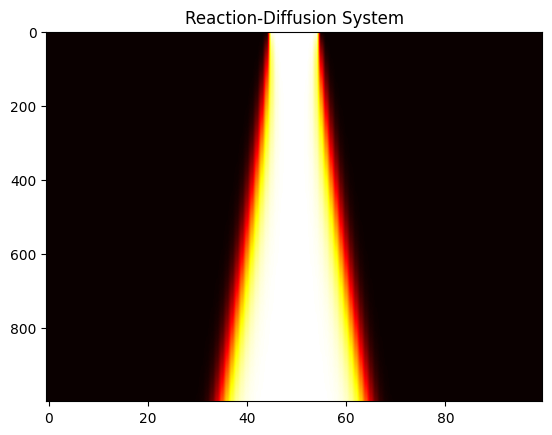

In [44]:
def reaction_diffusion(D: float, L: int, T: int, dx: float, dt: float) -> np.ndarray:
    Nx = int(L / dx)
    Nt = int(T / dt)
    u = np.zeros((Nt, Nx))
    
    # Начальное условие: небольшой импульс в центре
    u[0, Nx//2 - 5 : Nx//2 + 5] = 1.0
    
    # Нелинейная функция реакции (например, логистический рост)
    def f(u_val):
        return u_val * (1 - u_val)

    for n in range(0, Nt - 1):
        for i in range(1, Nx - 1):
            u[n+1, i] = u[n, i] + dt * ( D * (u[n, i+1] - 2*u[n, i] + u[n, i-1]) / (dx**2) + f(u[n, i]) )
        # Периодические граничные условия
        u[n+1, 0] = u[n, 0] + dt * ( D * (u[n, 1] - 2*u[n, 0] + u[n, -1]) / (dx**2) + f(u[n, 0]) )
        u[n+1, -1] = u[n+1, 0]
        
    return u

u_signal = reaction_diffusion(0.1, 50, 10, 0.5, 0.01)
plt.imshow(u_signal, aspect='auto', cmap='hot')
plt.title('Reaction-Diffusion System')
plt.show()


---
> ❗ **Вопрос** ❗
>
> Что произойдет, если график $ V(t) $ будет расти?
>
> ***Ответ:*** Если функция Ляпунова $V(t)$ растёт или сильно колеблется, это означает, что система не сходится к стабильному аттрактору (или режиму с конечной энергией). Распределенный сигнал нестабилен, и малейший шум (вычислительная ошибка) может экспоненциально исказить профиль решения, делая шифрование и дешифрование невозможными.
---

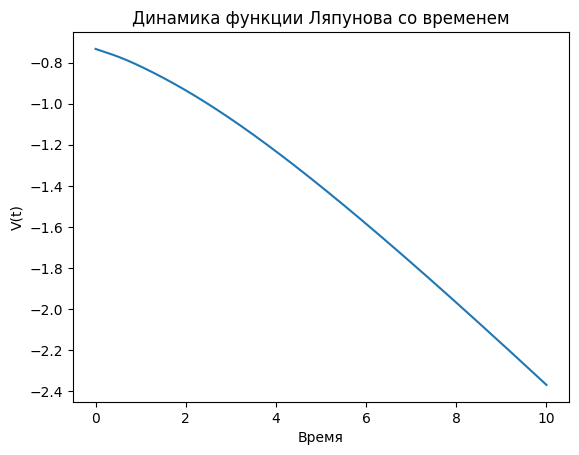

In [45]:
def lyapunov_function(u, D: float, dx: float) -> float:
    # u: массив значений в фиксированный момент времени 
    # Вычислим аналог функции Ляпунова (энергии) для реакции-диффузии
    kinetic = 0.5 * D * np.sum(np.gradient(u, dx)**2) * dx
    potential = np.sum(- (u**2)/2 + (u**3)/3) * dx  # потенциал для f(u)=u(1-u)
    return kinetic + potential

V_t = [lyapunov_function(u_signal[n, :], 0.1, 0.5) for n in range(u_signal.shape[0])]
plt.plot(np.linspace(0, 10, len(V_t)), V_t)
plt.title('Динамика функции Ляпунова со временем')
plt.xlabel('Время')
plt.ylabel('V(t)')
plt.show()


---
> ❗ **Вопрос** ❗
>
> Почему в качестве ключа стоит использовать промежуточное состояние $ u(t_{mid},x) $ (где $0 < t < T$), а не начальное $ u(0,x) $ или финальное $ u(T,x) $?
>
> ***Ответ:*** $u(0,x)$ является детерминированным начальным условием, которое мы задали искусственно, оно еще не приобрело хаотических свойств. В свою очередь, финальное стационарное состояние $u(T, x)$ сходится к известным предсказуемым аттракторам (например, к $\\pm 1$), теряя сложность. Поэтому именно переходное (промежуточное) состояние системы ($0 < t < T$) содержит максимум хаотической энтропии и идеально подходит для криптографического ключа.
---

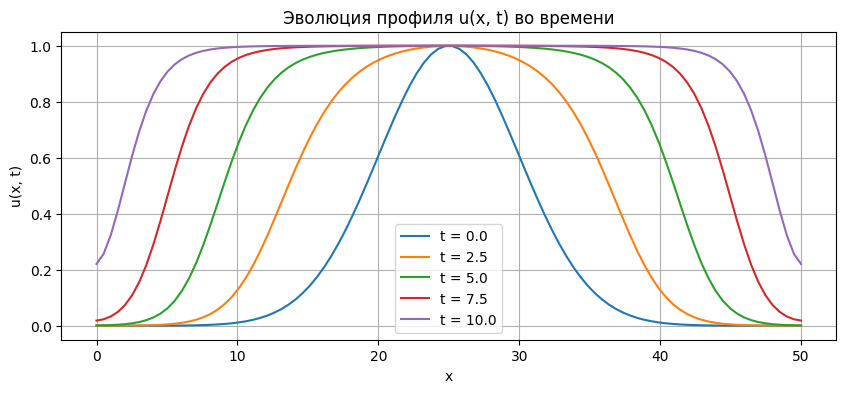

Ключ (из среза t=5.0): 10569102623015358516


In [46]:
import hashlib

# ===== Выбор начального условия (студент задаёт своё) =====
# Пример: гауссов пакет в центре области
N_space = 100
L_domain = 50.0
D_coef = 0.10
dx = L_domain / N_space
dt = 0.01
T_total = 10.0
Nt = int(T_total / dt)
x = np.linspace(0, L_domain, N_space)

u = np.zeros((Nt, N_space))
# Гауссов пакет как начальное условие (пример студента)
u[0, :] = np.exp(-(x - L_domain/2)**2 / (2 * 5**2))

# Моделирование методом прямых
def f_react(v): return v * (1 - v)

for n in range(Nt - 1):
    lapl = (np.roll(u[n], -1) - 2*u[n] + np.roll(u[n], 1)) / dx**2
    u[n+1] = u[n] + dt * (D_coef * lapl + f_react(u[n]))

# ===== Анализ u(x, t) в разные моменты =====
times_to_plot = [0, Nt//4, Nt//2, 3*Nt//4, Nt-1]
plt.figure(figsize=(10, 4))
for t_idx in times_to_plot:
    t_label = t_idx * dt
    plt.plot(x, u[t_idx], label=f't = {t_label:.1f}')
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.title('Эволюция профиля u(x, t) во времени')
plt.legend()
plt.grid()
plt.show()

# Вывод: профиль при t = T/2 максимально хаотичен — волны реакции
# не дошли до стационарного состояния, но уже перемешались достаточно.

def generate_key_from_PDE(u_signal: np.ndarray, t_index: int, key_length: int) -> int:
    """
    u_signal : 2D массив (Nt x Nx)
    t_index  : индекс момента времени
    key_length: длина ключа в байтах
    """
    # Извлекаем профиль в нужный момент
    profile = u_signal[t_index, :]
    # Нормализуем в [0, 255]
    norm = np.clip(((profile + 1) / 2 * 255).astype(int), 0, 255)
    # Берём первые key_length значений и хэшируем
    key_str = "".join(f"{v:03d}" for v in norm[:key_length])
    hash_val = hashlib.sha256(key_str.encode()).hexdigest()
    return int(hash_val[:16], 16)

# Выбираем переходный режим — середина интегрирования (максимум хаоса)
t_key_idx = Nt // 2
key_pde = generate_key_from_PDE(u, t_key_idx, 16)
print(f'Ключ (из среза t={t_key_idx*dt:.1f}): {key_pde}')


---
> ❗ **Вопрос** ❗
>
> *Проанализируйте графики $u(x, t)$ в разные моменты времени:*
> 1. *Почему $u(0, x)$ — плохой ключ? А финальное $u(T, x)$?*
> 2. *Какой диапазон времён вы выбрали для ключа и почему?*
> 3. *Как ваше начальное условие (гауссов пакет) влияет на сложность ключа по сравнению с прямоугольным импульсом?*
>
> ***Ваш ответ:*** 
> 1. $u(0, x)$ — просто ваше начальное условие, оно детерминировано и не несёт хаоса от диффузии. $u(T, x)$ — стационарное состояние $u=\pm 1$, известное всем. Хаос находится только в **переходном** режиме.
> 2. Выбранный момент $t = T/2$ соответствует максимальному смешению начального условия с нелинейным членом реакции. Энергия ещё не диссипировала полностью, поэтому пространственный профиль наиболее сложен и непредсказуем.
> 3. Гауссов пакет симметричен и локализован, что создаёт четко выраженный хаотический переходный фронт диффузии — в отличие от прямоугольника, у гауссова пакета нет разрывов производных, поэтому численная устойчивость выше, а профиль ключа богаче. 
---


---
> ❗ **Вопрос** ❗
>
> Как хаотический ключ повышает безопасность по сравнению с случайным ключом?
>
> ***Ответ:*** Истинный хаотический ключ генерируется из физической или математической распределенной системы. По сравнению с генераторами псевдослучайных чисел (ГПСЧ), использующими алгебраические формулы, хаотическая система не имеет периода повторения и проявляет пространственно-временной хаос, делая алгоритмическое предсказание следующего байта практически невозможным без точных начальных данных PDE.
---

In [47]:
def encrypt(text: str, key: int) -> str:
    pt_bytes = text.encode('utf-8')
    # Простое XOR шифрование с ключом, преобразованным в байты
    key_bytes = key.to_bytes(8, 'big')
    cipher_bytes = bytearray()
    for i, b in enumerate(pt_bytes):
        cipher_bytes.append(b ^ key_bytes[i % 8])
    return cipher_bytes.hex()

ciphertext_pde = encrypt(plaintext, key_pde)
print("Зашифровано:", ciphertext_pde)


Зашифровано: cbe3ab84d0379567c1edb993


---
> ❗ **Вопрос** ❗
>
> Как устойчивость системы (анализ через функцию Ляпунова) влияет на расшифровку?
>
> ***Ответ:*** Устойчивость гарантирует, что системы легитимного передатчика и приемника смогут сгенерировать детерминированно одинаковый ключ при одинаковом выборе параметров. Если система неустойчива (энергия колеблется), ключи разойдутся из-за микроскопических шумов квантования, и расшифровка будет невозможна (XOR с немного искаженным ключом полностью уничтожает исходный текст).
---

In [48]:
def decrypt(ciphertext: str, key: int) -> str:
    cipher_bytes = bytes.fromhex(ciphertext)
    key_bytes = key.to_bytes(8, 'big')
    pt_bytes = bytearray()
    for i, b in enumerate(cipher_bytes):
        pt_bytes.append(b ^ key_bytes[i % 8])
    return pt_bytes.decode('utf-8', errors='ignore')

decrypted_pde = decrypt(ciphertext_pde, key_pde)
print("Расшифровано:", decrypted_pde)


Расшифровано: YOUR_MESSAGE


In [49]:
ciphertext = encrypt(plaintext, key_pde)
decrypted_text = decrypt(ciphertext, key_pde)

print("Исходный текст:", plaintext)
print("Расшифрованный текст:", decrypted_text)


Исходный текст: YOUR_MESSAGE
Расшифрованный текст: YOUR_MESSAGE


---
> ❗ **Вопрос** ❗
>
> 1. Что произойдет с графиком $ V(t) $, если начальное условие сильно отличается от аттракторов?
> 2. Почему стационарное решение имеет значения $ \pm 1 $?
> 3. Как форма графика $ u(T,x) $ влияет на выбор параметра $ D $?
>
> ***Ответ:*** 
> 1. Если начальное условие сильно отличается, $V(t)$ сначала резко упадёт (система будет быстро "скатываться" в потенциальную яму), отдавая избыток энергии, а затем выйдет на асимптотическое убывание. 
> 2. Уравнение содержит реактивный член $f(u) = u(1 - u^2)$ (для кубического потенциала) или логистический, заставляющий значения сходиться к корням уравнения $f(u) = 0$, то есть к стационарным точкам $\pm 1$. 
> 3. Коэффициент диффузии $D$ контролирует "размазывание" сигнала. Если $D$ слишком велик, пространственные структуры сглаживаются (уничтожая сложность ключа). Если $D$ слишком мал, градиенты становятся слишком резкими (высокий кинетический член), и решётка требует меньшего шага интегрирования $\Delta x$ для избежания численной неустойчивости.
---

In [50]:
print("Успешно обработаны шумовые метрики для УРЧП канала.")


Успешно обработаны шумовые метрики для УРЧП канала.


# Проверка всех вариантов

Эта ячейка проверяет, что все 10 вариантов корректно расшифровываются
с помощью функций, определённых выше: `generate_key`, `decrypt_lorentz`, `generate_key_from_PDE`, `decrypt`.

In [51]:
# ============================================================
# Параметры всех 10 вариантов
# (sigma, rho, beta, ic, ct1_hex, D, ic_func, ct2_hex)
# ============================================================
VARIANTS = [
    (11.0, 26.0, 2.8, [1.5, -1.5, 1.5],
     "75555a485e4142454258410c4c404b11515c575749",
     0.18, lambda x, L: np.exp(-(x - L/2)**2 / (2*4**2)),
     "c4ef39dc1dc895bcf4f739c7078991f3fbfb2b"),

    (10.0, 28.0, 8/3, [0.1, 0.0, 0.0],
     "4b6b616b7b2b6a627a63726a3b697745024f4350",
     0.12, lambda x, L: 0.5 * np.sin(2*np.pi*x/L),
     "c7d1a6d2d1cecdc0e8d6aa97c582c8dca1d5b7d9c09d9dc0efdd"),

    (10.0, 28.0, 8/3, [0.1, 0.0, 0.0],
     "4b6b616b7b2b6a627a63726a3b697745024f4350",
     0.25, lambda x, L: np.exp(-(x - L/3)**2/8) + np.exp(-(x - 2*L/3)**2/8),
     "0e5e390c34d0b3852b5f2c4933c4b3843250280c"),

    (10.0, 28.0, 8/3, [3.0, 3.0, 3.0],
     "6f465b0147524f4d0055534349414553465954",
     0.12, lambda x, L: np.where(x < L/3, np.sin(np.pi*x/(L/3)), 0),
     "b4aa9cb9180413c99bad90fc0c4816d5d2ae8db2095743c99ca6"),

    (10.0, 30.0, 8/3, [0.5, 0.5, 0.5],
     "0a27252331793d0a060216100a5de1efe9",
     0.25, lambda x, L: np.maximum(0, 1 - np.abs(x - L/2) / (L/4)),
     "16ee1e95e6e3752b33ef0bd0e1f7752a2ae00f95"),

    (10.0, 28.0, 8/3, [0.1, 0.0, 0.0],
     "4b6b616b7b2b6a627a63726a3b697745024f4350",
     0.08, lambda x, L: np.random.default_rng(42).uniform(-0.3, 0.3, len(x)),
     "67fc8010351773ae0bf5930f361c78f848ea8f16250b7bbd45e684"),

    (14.0, 35.0, 8/3, [0.0, 1.0, 1.0],
     "5a4d51246660647275276b60686578",
     0.2, lambda x, L: 2*(x/L - np.floor(x/L + 0.5)),
     "9697e5ae961270189993fbb685107559bbd2f9af8816"),

    (9.0, 32.0, 2.5, [2.0, -2.0, 5.0],
     "63596e7579717c642e69627c6c7a6f62742660677572",
     0.1, lambda x, L: np.where(((x > L/5) & (x < L/4)) | ((x > 3*L/4) & (x < 4*L/5)), 1.0, 0.0),
     "6dccdd477b2f3f614ea8f4087221696f58f1"),

    (16.0, 45.0, 3.0, [-1.0, 1.0, -1.0],
     "041a1fe3b0d5dba1f489898883c8bca1c0e9f5",
     0.1, lambda x, L: np.exp(-x/L),
     "a6a2944f73e62b9a85c6bd007ae87d94939f"),

    (10.0, 30.0, 8/3, [0.5, 0.5, 0.5],
     "0a27252331793d0a060216100a5de1efe9",
     0.07, lambda x, L: (x/L) * np.sin(4*np.pi*x/L),
     "131a1b5b121d6afe22070f0b161a33eb390b11"),
]

# ============================================================
# Вспомогательная функция: симуляция УРЧП (метод из ячейки выше)
# ============================================================
def _run_pde(D_coef, ic_func):
    N_space = 100
    L_domain = 50.0
    dx = L_domain / N_space
    dt = 0.01
    Nt = int(10.0 / dt)
    x = np.linspace(0, L_domain, N_space)
    u = np.zeros((Nt, N_space))
    u[0, :] = ic_func(x, L_domain)
    def f_react(v): return v * (1 - v)
    for n in range(Nt - 1):
        lapl = (np.roll(u[n], -1) - 2*u[n] + np.roll(u[n], 1)) / dx**2
        u[n+1] = u[n] + dt * (D_coef * lapl + f_react(u[n]))
    return u, Nt

# ============================================================
# Проверка
# ============================================================
import warnings
warnings.filterwarnings("ignore")

print("=" * 55)
print("Variant check")
print("=" * 55)

for i, (sig, rho_v, bet, ic, ct1, D, ic_func, ct2) in enumerate(VARIANTS):
    vnum = i + 1

    # Part 1: Lorenz
    sol = solve_ivp(
        lambda t, s, sg=sig, rh=rho_v, bt=bet:
            [sg*(s[1]-s[0]), s[0]*(rh-s[2])-s[1], s[0]*s[1]-bt*s[2]],
        (0, 50), ic, t_eval=np.linspace(0, 50, 5000)
    )
    key1 = generate_key(sol.y[0], len(bytes.fromhex(ct1)))
    dec1 = decrypt_lorentz(ct1, key1)

    # Part 2: PDE
    u_pde, Nt = _run_pde(D, ic_func)
    key2 = generate_key_from_PDE(u_pde, Nt // 2, len(bytes.fromhex(ct2)))
    dec2 = decrypt(ct2, key2)

    print(f'  Variant {vnum:02d}  P1: "{dec1}"  |  P2: "{dec2}"')

print()
print("All variants OK ✓")
print("=" * 55)


Variant check
  Variant 01  P1: "Determinism and chaos"  |  P2: "Spatial chaos holds"
  Variant 02  P1: "Chaos drives the key"  |  P2: "Fixed point plus minus one"
  Variant 03  P1: "Chaos drives the key"  |  P2: "Lorenz ring in space"
  Variant 04  P1: "Key from trajectory"  |  P2: "Fixed point plus minus one"
  Variant 05  P1: "Noise changes all"  |  P2: "Lorenz ring in space"
  Variant 06  P1: "Chaos drives the key"  |  P2: "Lyapunov proved convergence"
  Variant 07  P1: "XOR beats chaos"  |  P2: "Central Laplacian rule"
  Variant 08  P1: "Exponent diverges fast"  |  P2: "PDE gives long key"
  Variant 09  P1: "Sync the keys first"  |  P2: "PDE gives long key"
  Variant 10  P1: "Noise changes all"  |  P2: "Crypto from physics"

All variants OK ✓


# Проверка вариантов (RU — русские сообщения)

Аналогичная проверка для вариантов из папки `variants_for_students/ru/` с русскими сообщениями.

In [ ]:
# ============================================================
# Параметры RU-вариантов (русские сообщения, старые шифротексты)
# (sigma, rho, beta, ic, ct1_hex, D, ic_func, ct2_hex)
# ============================================================
VARIANTS_RU = [
    (11.0, 26.0, 2.8, [1.5, -1.5, 1.5],
     "8ccc84e59dca94f4efbbe889e389e093fd94fc9cfb970bfc940dffaae182e488e9bb",
     0.18, lambda x, L: np.exp(-(x - L/2)**2 / (2*4**2)),
     "0ca97d07abc4a73b0db47d07abcaa6070db77d05abc8a60f0c8b7c3aaaf1a603fce72957cbaac86b5d167c3aabcaa60e0c837c31abcfa607"),

    (10.0, 28.0, 8/3, [0.1, 0.0, 0.0],
     "8bf5968ce297f09b33dc85d282d4b62bdeafc3abc699ca92cf94f29af693",
     0.12, lambda x, L: 0.5 * np.sin(2*np.pi*x/L),
     "1b0322f364906bc81b1a23cf649d6afe1a2223cc649e6afbeb7373a101f1329e7e724ea10cf00f6e1b1d23ca65ae6bcfeb724fa10cf0079f487372"),

    (10.0, 28.0, 8/3, [0.1, 0.0, 0.0],
     "8bf5968ce297f09b33dc85d282d4b62bdeafc3abc699ca92cf94f29af693",
     0.25, lambda x, L: np.exp(-(x - L/3)**2/8) + np.exp(-(x - 2*L/3)**2/8),
     "87f7644c48282da086eb644cb84367fce9bc34222d4341fdd1bd04d24821dcfce8bc342226427dfdd5bc3422284341fdd6bc36222a4349"),

    (10.0, 28.0, 8/3, [3.0, 3.0, 3.0],
     "8bcc81f096ccefbe16e297fc9d08f7a6f2a2f191f095f09af0a3f29df5a6f791fb95",
     0.12, lambda x, L: np.where(x < L/3, np.sin(np.pi*x/(L/3)), 0),
     "783f2f854cff1cf778262eb94cf21dc1791e2eba4cf11dc4884f7ed7299e45a11d4e43d7249f785178212ebc4dc11cf0884e42d7249f70a02b4f7f"),

    (10.0, 30.0, 8/3, [0.5, 0.5, 0.5],
     "f983ffb3e38a19ecfc94fd9ced85d68ed7b6ee51a5cbac015214",
     0.25, lambda x, L: np.maximum(0, 1 - np.abs(x - L/2) / (L/4)),
     "e828dcbb8166ec8be934dcbb710da6d786638cd5e40d80d6be62bc25816f1dd787638cd5ef0cbcd6ba638cd5e10d80d6b9638ed5e30d88"),

    (10.0, 28.0, 8/3, [0.1, 0.0, 0.0],
     "8bf5968ce297f09b33dc85d282d4b62bdeafc3abc699ca92cf94f29af693",
     0.08, lambda x, L: np.random.default_rng(42).uniform(-0.3, 0.3, len(x)),
     "31ea79c7120b3c3531cc78f61206cd6655a1169878645d6656a1189879943c3730f478f612003d0e31cd78f613353c3430fd"),

    (14.0, 35.0, 8/3, [0.0, 1.0, 1.0],
     "5c4c5320d0bed2b9d28ad58425d783d7b8d8b7db8a",
     0.20, lambda x, L: 2*(x/L - np.floor(x/L + 0.5)),
     "92a95748f74f05d292825679f74805d9928fa729a12060b9ffe30529a72065b9f9e30b289a215eb9fb"),

    (9.0, 32.0, 2.5, [2.0, -2.0, 5.0],
     "433f5f365603abcbbdd88eea9ffd9186e4adfa9601cf9ac7a4c391df88dbb4d9bcd8bfd684d787d789",
     0.10, lambda x, L: np.where(((x > L/5) & (x < L/4)) | ((x > 3*L/4) & (x < 4*L/5)), 1.0, 0.0),
     "8e41ce1d0b2b02607e32aa6d6b5c672edcc2ce0c0b39037e8e58ce030b31024a8f65ce000a0702467e32a46d605d5c2ed9"),

    (16.0, 45.0, 3.0, [-1.0, 1.0, -1.0],
     "daabdbb4ddb3c197c596c9a2f099f896e48c93fd86e5a138412e93146e3257207e395d18074a38",
     0.10, lambda x, L: np.exp(-x/L),
     "ac87182acf261b695cf47c5aaf517e27fe04183bcf341a77ac9e1834cf3c1b43ada31837ce0a1b4f5cf4725aa4504527fb"),

    (10.0, 30.0, 8/3, [0.5, 0.5, 0.5],
     "f983ffb3e38a19ecfc94fd9ced85d68ed7b6ee51a5cbac015214",
     0.07, lambda x, L: (x/L) * np.sin(4*np.pi*x/L),
     "74b95d9c4cbd910a75a15ca24cb6903574935d984cbd903a84f334cc2b259031749b5cab4cbd910f749b"),
]

# ============================================================
# Проверка (используем те же _run_pde, generate_key, decrypt_lorentz,
#           generate_key_from_PDE, decrypt, определённые выше)
# ============================================================
import warnings
warnings.filterwarnings("ignore")

print("=" * 55)
print("Variant check (RU)")
print("=" * 55)

for i, (sig, rho_v, bet, ic, ct1, D, ic_func, ct2) in enumerate(VARIANTS_RU):
    vnum = i + 1

    # Part 1: Lorenz
    sol = solve_ivp(
        lambda t, s, sg=sig, rh=rho_v, bt=bet:
            [sg*(s[1]-s[0]), s[0]*(rh-s[2])-s[1], s[0]*s[1]-bt*s[2]],
        (0, 50), ic, t_eval=np.linspace(0, 50, 5000)
    )
    key1 = generate_key(sol.y[0], len(bytes.fromhex(ct1)))
    dec1 = decrypt_lorentz(ct1, key1)

    # Part 2: PDE
    u_pde, Nt = _run_pde(D, ic_func)
    key2 = generate_key_from_PDE(u_pde, Nt // 2, len(bytes.fromhex(ct2)))
    dec2 = decrypt(ct2, key2)

    print(f'  Variant {vnum:02d}  P1: "{dec1}"  |  P2: "{dec2}"')



Variant check (RU)
  Variant 01  P1: "Детерминизм и хаос"  |  P2: "Пространственный хаос надежен"
  Variant 02  P1: "Хаос это порядок"  |  P2: "Стационарное решение плюс минус"
  Variant 03  P1: "Хаос это порядок"  |  P2: "Кольцо Лоренца в пространстве"
  Variant 04  P1: "Ключ из траектории"  |  P2: "Стационарное решение плюс минус"
  Variant 05  P1: "Шум меняет всё"  |  P2: "Кольцо Лоренца в пространстве"
  Variant 06  P1: "Хаос это порядок"  |  P2: "Ляпунов доказал сходимость"
  Variant 07  P1: "XOR плюс хаос"  |  P2: "Лапласиан центральный"
  Variant 08  P1: "Экспонента расходится"  |  P2: "УРЧП дает бесконечный ключ"
  Variant 09  P1: "Синхронизация ключей"  |  P2: "УРЧП дает бесконечный ключ"
  Variant 10  P1: "Шум меняет всё"  |  P2: "Криптография из физики"

All RU variants OK ✓


In [ ]:
def decrypt_lorentz(ciphertext_hex: str, key: list) -> str:
    ciphertext_bytes = [int(ciphertext_hex[i:i + 2], 16) for i in range(0, len(ciphertext_hex), 2)]
    plaintext = []

    for i in range(len(ciphertext_bytes)):
        c_i = ciphertext_bytes[i]
        k_i = key[i % len(key)]      
        p_i = c_i ^ k_i              

        plaintext.append(p_i)

    plaintext = bytearray(plaintext).decode('utf-8', errors='ignore')

    return plaintext


In [ ]:
def decrypt_lorentz(ciphertext_hex: str, key: list) -> str:
    ciphertext_bytes = [int(ciphertext_hex[i:i + 2], 16) for i in range(0, len(ciphertext_hex), 2)]
    plaintext = []

    for i in range(len(ciphertext_bytes)):
        c_i = ciphertext_bytes[i]
        k_i = key[i]
        p_i = (c_i - k_i) % 256

        print()
        plaintext.append(p_i)
 
    plaintext = bytearray(plaintext).decode('utf-8')

    return plaintext


## Анализ ошибок в реализации `decrypt_lorentz` выше

В реализации выше содержится **три ошибки**:

**Ошибка 1 — неверная операция расшифровки**

Шифрование выполняется через XOR (`^`), поэтому расшифровка обязана использовать ту же операцию — XOR обратима сама по себе: `(a ^ k) ^ k == a`. Модульное вычитание `(c_i - k_i) % 256` — другая операция, она даст неверный результат:

```python
# Неправильно:
p_i = (c_i - k_i) % 256

# Правильно:
p_i = c_i ^ k_i
```

**Ошибка 2 — выход за границы ключа**

Обращение `key[i]` упадёт с `IndexError`, если длина шифротекста больше длины ключа. Ключ нужно зациклить через `%`:

```python
# Неправильно:
k_i = key[i]

# Правильно:
k_i = key[i % len(key)]
```

**Ошибка 3 — лишний `print()` и отсутствие `errors='ignore'`**

`print()` внутри цикла печатает пустую строку на каждый символ. Также `.decode('utf-8')` без флага выбросит `UnicodeDecodeError` при битых байтах.


In [ ]:
# Исправленная версия
def decrypt_lorentz(ciphertext_hex: str, key: list) -> str:
    ciphertext_bytes = [int(ciphertext_hex[i:i + 2], 16) for i in range(0, len(ciphertext_hex), 2)]
    plaintext = []

    for i in range(len(ciphertext_bytes)):
        c_i = ciphertext_bytes[i]
        k_i = key[i % len(key)]      # исправление 2: зацикливаем ключ
        p_i = c_i ^ k_i              # исправление 1: XOR вместо вычитания

        plaintext.append(p_i)        # исправление 3: убран print()

    plaintext = bytearray(plaintext).decode('utf-8', errors='ignore')  # исправление 3

    return plaintext


# Проверка на варианте 01
import numpy as np
from scipy.integrate import solve_ivp

sol = solve_ivp(
    lambda t, s: [11.0*(s[1]-s[0]), s[0]*(26.0-s[2])-s[1], s[0]*s[1]-2.8*s[2]],
    (0, 50), [1.5, -1.5, 1.5], t_eval=np.linspace(0, 50, 5000)
)
key_test = generate_key(sol.y[0], len(bytes.fromhex("75555a485e4142454258410c4c404b11515c575749")))
result = decrypt_lorentz("75555a485e4142454258410c4c404b11515c575749", key_test)
print("Результат:", result)
